# Notebook 04 — Quimógrafos sintéticos (ingenia-kymograph)

Generamos quimógrafos **sintéticos realistas** usando el paquete `synthkymo` del repositorio `ingenia-kymograph`, que modela el proceso óptico completo: tubo axonal, partículas Gaussianas, ruido de lectura, artefactos de microscopía.

## Por qué ingenia-kymograph en lugar del generador simple

El generador anterior (`kimografo_sintetico.py`) dibujaba trayectorias directamente como pixeles en el quimógrafo. `synthkymo` en cambio:

1. **Genera un video** (pila T×H×W) con un tubo axonal curvado tipo Catmull-Rom, partículas Gaussianas y ruido realista de microscopía.
2. **Extrae el quimógrafo** del video muestreando tiras perpendiculares a lo largo del ROI del axón.

El resultado se parece mucho más a los quimógrafos del laboratorio, lo que hace el baseline más significativo.

## Convención de ejes

`kymografo[t, col]`: **filas = tiempo**, **columnas = posición**. Pero atención: `extract.py` **voltea** el eje espacial para que el soma quede a la derecha. Esto significa:

- La posición 0 de arco (soma) está en la columna `width-1` (derecha).
- Una partícula **anterógrada** (pos_um creciente = alejándose del soma) aparece como estela hacia la **izquierda** (columna decreciente).
- Una partícula **retrógrada** (pos_um decreciente = hacia el soma) aparece hacia la **derecha** (columna creciente).

El ground truth en `positions.csv` usa `pos_um` (longitud de arco en µm desde el soma), que hay que convertir a coordenada de quimógrafo:

```python
kymo_col = kymo_width - 1 - pos_um / pixel_scale_um
```

## Spec del caso ideal (nivel 1)

| Tipo        | Cantidad | Notas                                                   |
| ----------- | -------- | ------------------------------------------------------- |
| static      | 5        | sin movimiento                                          |
| anterograde | 5        | desplazamiento neto positivo (hacia distal), con pausas |
| retrograde  | 5        | desplazamiento neto negativo (hacia soma), con pausas   |


---

## 0. Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append(str(Path("..") / "src"))
from axonal_tracking.parametros import PIXEL_SIZE_UM

from synthkymo.pipeline import generate, generate_dataset, metadata_dict

DIR_SALIDA = Path("..") / "data" / "sinteticos" / "ingenia"
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

print(f"PIXEL_SIZE_UM del laboratorio = {PIXEL_SIZE_UM} µm/px")
print(f"Salida → {DIR_SALIDA.resolve()}")

PIXEL_SIZE_UM del laboratorio = 0.107 µm/px
Salida → /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/data/sinteticos/ingenia


---

## 1. Configuración

Basada en el config de `ingenia-kymograph/datasets/run/config.yaml` (ya validado). Cambios respecto al original:

- `pixel_scale_um` → 0.107 µm/px (escala del lab)
- `type_counts` → 5 static + 5 anterograde + 5 retrograde
- `duration_s=128, fps=2` → 256 frames (igual que el NB04 previo)
- `movie.width_px=512, height_px=128` → tira estrecha tipo ROI real


In [2]:
CONFIG = {
    "general": {
        "duration_s": 128.0,
        "fps": 2.0,
        "pixel_scale_um": PIXEL_SIZE_UM,  # 0.107 µm/px
        "bit_depth": 8,
        "seed": 42,
    },
    "particles": {
        "speed_um_s": {"min": -1.0, "max": 1.0},
        "segment_duration_s": {"min": 2.0, "max": 10.0},
        "pause_probability": 0.3,
        "appear_disappear": {"enabled": False, "prob": 0.3},
        "size_um": {"min": 0.1, "max": 0.25},
        "brightness": {"min": 0.13, "max": 0.5},
        "size_jitter": 0.0,
        "brightness_jitter": 0.0,
        "type_counts": {
            "static": 5,
            "anterograde": 5,
            "retrograde": 5,
            "pure_anterograde": 0,
            "pure_retrograde": 0,
            "bidirectional": 0,
        },
    },
    "movie": {
        "width_px": 512,
        "height_px": 128,
        "path": {"n_control_points": 2},
        "tube": {"width_um": 0.5, "brightness": 0.2, "variation": 0.5},
        "noise": {
            "background": 0.05,
            "read_sigma": 0.02,
            "shot": {"strength": 0.0},
            "hot_pixels": {"density": 0.0, "dead_fraction": 0.3},
            "illumination": {"unevenness": 0.0},
            "photobleaching": {"end_fraction": 1.0},
        },
        "artifacts": {
            "static_particles": {
                "count": 5,
                "size_um": {"min": 0.2, "max": 0.6},
                "brightness": {"min": 0.3, "max": 0.8},
            },
            "tails": {
                "count": 3,
                "length_um": {"min": 1.0, "max": 3.0},
                "brightness": {"min": 0.2, "max": 0.5},
            },
            "smoke": {
                "count": 4,
                "size_um": {"min": 2.0, "max": 5.0},
                "brightness": {"min": 0.05, "max": 0.15},
            },
        },
        "extraction": {"strip_half_width_px": 3, "aggregation": "max"},
    },
}

N_FRAMES = round(CONFIG["general"]["duration_s"] * CONFIG["general"]["fps"])
print(f"Frames: {N_FRAMES}")
print(f"Partículas: {sum(CONFIG['particles']['type_counts'].values())}")
print(
    f"  static={CONFIG['particles']['type_counts']['static']}, "
    f"anterograde={CONFIG['particles']['type_counts']['anterograde']}, "
    f"retrograde={CONFIG['particles']['type_counts']['retrograde']}"
)

Frames: 256
Partículas: 15
  static=5, anterograde=5, retrograde=5


---

## 2. Muestra de previsualización (seed=42)

Generamos **un** sample para confirmar que el pipeline funciona y verificar el aspecto visual antes de generar el dataset completo.


In [3]:
res = generate(CONFIG, seed=42)

print("Resumen del sample:")
for k, v in res.summary.items():
    print(f"  {k}: {v}")
print(f"\nmovie.shape  = {res.movie.shape}   (T, H, W)")
print(f"kymograph.shape = {res.kymograph.shape}   (T, W_axon)")
print(
    f"kymo width/16 = {res.kymograph.shape[1]}/16 = {res.kymograph.shape[1]/16:.2f} (si no es entero, KymoButler puede redimensionar)"
)

Resumen del sample:
  type_counts: {'retrograde': 5, 'anterograde': 5, 'static': 5}
  n_particles: 15
  n_frames: 256
  axon_length_um: 57.91725371580353
  movie_width: 512
  movie_height: 128
  kymograph_width: 541
  nucleus_position: top
  seed: 42

movie.shape  = (256, 128, 512)   (T, H, W)
kymograph.shape = (256, 541)   (T, W_axon)
kymo width/16 = 541/16 = 33.81 (si no es entero, KymoButler puede redimensionar)


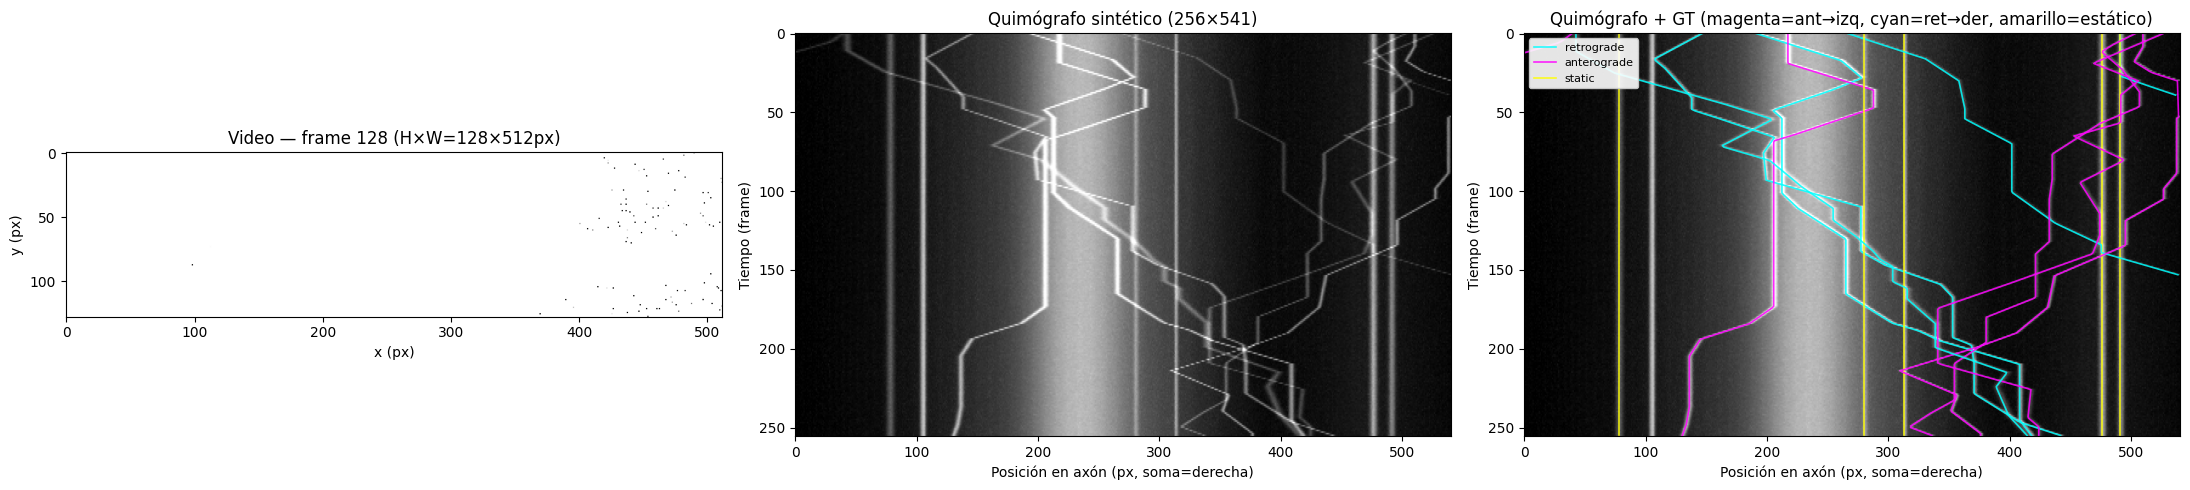


Verificación de dirección:
  anterograde: desplazamiento neto medio=11.3 µm → en quimógrafo hacia izquierda (col↓)
  retrograde: desplazamiento neto medio=-25.9 µm → en quimógrafo hacia derecha (col↑)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Frame medio del video
mid = res.movie.shape[0] // 2
axes[0].imshow(res.movie[mid], cmap="gray", vmin=0, vmax=255)
axes[0].set_title(
    f"Video — frame {mid} (H×W={res.movie.shape[1]}×{res.movie.shape[2]}px)"
)
axes[0].set_xlabel("x (px)")
axes[0].set_ylabel("y (px)")

# Quimógrafo crudo
axes[1].imshow(res.kymograph, cmap="gray", aspect="auto", vmin=0, vmax=255)
axes[1].set_title(
    f"Quimógrafo sintético ({res.kymograph.shape[0]}×{res.kymograph.shape[1]})"
)
axes[1].set_xlabel("Posición en axón (px, soma=derecha)")
axes[1].set_ylabel("Tiempo (frame)")

# Quimógrafo + ground truth overlay
axes[2].imshow(res.kymograph, cmap="gray", aspect="auto", vmin=0, vmax=255)
kymo_w = res.kymograph.shape[1]
pixel_scale = CONFIG["general"]["pixel_scale_um"]

COLORES_GT = {"static": "yellow", "anterograde": "magenta", "retrograde": "cyan"}
vistos = set()
for pid, sub in res.positions[res.positions.visible == 1].groupby("particle_id"):
    ptype = sub.iloc[0]["type"]
    # Posición en el quimógrafo: flip porque soma está a la derecha
    kymo_col = kymo_w - 1 - sub["pos_um"] / pixel_scale
    etiqueta = ptype if ptype not in vistos else None
    vistos.add(ptype)
    axes[2].plot(
        kymo_col,
        sub["frame"],
        color=COLORES_GT.get(ptype, "white"),
        linewidth=1.2,
        alpha=0.85,
        label=etiqueta,
    )

axes[2].set_title("Quimógrafo + GT (magenta=ant→izq, cyan=ret→der, amarillo=estático)")
axes[2].set_xlabel("Posición en axón (px, soma=derecha)")
axes[2].set_ylabel("Tiempo (frame)")
axes[2].legend(loc="upper left", framealpha=0.9, fontsize=8)

plt.tight_layout()
plt.show()

print("\nVerificación de dirección:")
for ptype in ("anterograde", "retrograde"):
    sub = res.positions[(res.positions["type"] == ptype) & (res.positions.visible == 1)]
    if sub.empty:
        continue
    first_last = sub.groupby("particle_id")["pos_um"].agg(["first", "last"])
    net = (first_last["last"] - first_last["first"]).mean()
    kymo_dir = "izquierda (col↓)" if net > 0 else "derecha (col↑)"
    print(
        f"  {ptype}: desplazamiento neto medio={net:.1f} µm → en quimógrafo hacia {kymo_dir}"
    )

---

## 3. Guardar la previsualización como PNG

KymoButler espera un PNG en escala de grises. Como `bit_depth=8`, el quimógrafo ya es `uint8 [0, 255]`.


In [5]:
# Guardar PNG de previsualización para smoke-test en NB05
preview_dir = DIR_SALIDA / "preview"
preview_dir.mkdir(exist_ok=True)
preview_png = preview_dir / "kymograph.png"
preview_pos = preview_dir / "positions.csv"
preview_meta = preview_dir / "metadata.json"

Image.fromarray(res.kymograph, mode="L").save(preview_png)
res.positions.to_csv(preview_pos, index=False)

import json

preview_meta.write_text(json.dumps(metadata_dict(res), indent=2))

print(f"PNG guardado  : {preview_png}")
print(f"Posiciones GT : {preview_pos}")
print(f"Metadata      : {preview_meta}")

PNG guardado  : ../data/sinteticos/ingenia/preview/kymograph.png
Posiciones GT : ../data/sinteticos/ingenia/preview/positions.csv
Metadata      : ../data/sinteticos/ingenia/preview/metadata.json


---

## 4. Dataset completo

Generamos **10 muestras** con seeds consecutivos. Cada muestra contiene:

- `movie.tif`: video (T, H, W) en uint8
- `kymograph.tif`: quimógrafo (T, W_axon) en uint8
- `positions.csv`: posiciones GT por `(particle_id, frame)` con `pos_um`, `type`, `visible`
- `scenario.json`: modelo cinemático completo
- `metadata.json`: longitud del axón, soma/distal, seed
- `axon.roi`: ROI de ImageJ para inspección en Fiji

El handoff al notebook 06 es el directorio completo + el `manifest.csv`.

In [6]:
N_SAMPLES = 10
BASE_SEED = 1000

manifest = generate_dataset(
    CONFIG,
    n=N_SAMPLES,
    outdir=DIR_SALIDA,
    base_seed=BASE_SEED,
    progress=lambda i, n: print(f"  {i}/{n} ...", end="\r"),
)
print(f"\n{N_SAMPLES} muestras generadas en {DIR_SALIDA.resolve()}")

  10/10 ...
10 muestras generadas en /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/data/sinteticos/ingenia


In [7]:
# Guardar PNGs para KymoButler (una pasada adicional sobre el dataset generado)
import tifffile

for entry in manifest:
    sample_path = DIR_SALIDA / entry["sample_dir"]
    kymo_tif = sample_path / "kymograph.tif"
    kymo_png = sample_path / "kymograph.png"
    if not kymo_png.exists():
        kymo = tifffile.imread(kymo_tif)
        Image.fromarray(kymo, mode="L").save(kymo_png)

df_manifest = pd.read_csv(DIR_SALIDA / "manifest.csv")
print(df_manifest.to_string(index=False))

 index   sample_dir  seed  n_particles  axon_length_um  movie_width  movie_height  n_frames  kymograph_width nucleus_position
     0 sample_00000  1000           15       32.133780          512           128       256              300              top
     1 sample_00001  1001           15       51.445414          512           128       256              481            right
     2 sample_00002  1002           15       45.706374          512           128       256              427             left
     3 sample_00003  1003           15       43.319755          512           128       256              405           bottom
     4 sample_00004  1004           15       65.505111          512           128       256              612             left
     5 sample_00005  1005           15       41.109291          512           128       256              384           bottom
     6 sample_00006  1006           15       57.812270          512           128       256              540          

---

## Conclusión

Generamos **10 quimógrafos sintéticos realistas** usando `synthkymo`:

- **Pipeline**: video óptico (tubo + partículas Gaussianas + artefactos) → extracción por tiras perpendiculares.
- **GT**: `positions.csv` con `pos_um` por `(particle_id, frame)`. Conversión a columna de quimógrafo: `kymo_col = kymo_width - 1 - pos_um / pixel_scale_um`.
- **Dirección en quimógrafo**: anterógrada → estela hacia la izquierda (col decreciente); retrógrada → hacia la derecha (col creciente).

### Próximos pasos

1. **Notebook 05**: correr **KymoButler** sobre estos quimógrafos y medir recall, error de posición, dirección, ID-switches.
2. **Nivel 2**: habilitar `noise.shot.strength > 0`, `illumination.unevenness > 0`, `appear_disappear.enabled=True`.
3. Comparar métricas entre nivel 1 y nivel 2, y eventualmente contra quimógrafos **reales**.
